In [2]:
# 运行此代码单元格来挂载 Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os

# 成功后 Google Drive内容将可以在以下路径访问：
# '/content/drive/My Drive/'
# 假如文件夹名为 'my_project_data' 并且存储在Google Drive的根目录下
# 在Colab中就可以通过 '/content/drive/My Drive/my_project_data/' 来访问它。
drive_path = '/content/drive/My Drive/自选题' # 定义想要切换到的文件夹路径

if os.path.exists(drive_path):
    os.chdir(drive_path)
    print(f"当前工作目录已切换至: {os.getcwd()}")
else:
    print(f"错误: 路径不存在 {drive_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
当前工作目录已切换至: /content/drive/My Drive/自选题


# Experiment: Project Bootstrap And ETIS Data Inspection

本 notebook 只负责 ETIS 项目的准备与检查：

- 固定项目目标和运行顺序
- 检查你已经放好的 ETIS 目录和列表文件
- 确认 `train / val / test = 156 / 20 / 20`
- 固定后续所有模型共用的测试可视化样本


## 加载基础工具

这里仅加载最基础的环境、目录和 JSON 工具，不包含模型与训练逻辑。


In [3]:
from pathlib import Path
import json
import os
import random
import sys

from scripts.project_utils import (
    ARTIFACTS,
    DATA_ROOT,
    ETIS_ROOT,
    PVT_PRETRAINED_ROOT,
    SWIN_UNET_PRETRAINED_ROOT,
    ensure_project_dirs,
    get_default_project_config,
    load_project_config,
    print_env_summary,
    save_json,
    set_seed,
    try_import_torch,
)

ensure_project_dirs()
set_seed()
torch = try_import_torch()
ENV_SUMMARY = print_env_summary(torch)
ROOT = Path.cwd().resolve()


{
  "python": "3.12.13",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "root": "/content/drive/My Drive/自选题",
  "data_root": "/content/drive/My Drive/自选题/data",
  "etis_root": "/content/drive/My Drive/自选题/data/ETIS",
  "pvt_pretrained_root": "/content/drive/My Drive/自选题/data/pvt_pretrained_pth",
  "swin_unet_pretrained_root": "/content/drive/My Drive/自选题/data/SwinUnet_pretrained_pth",
  "torch_installed": true,
  "cuda_available": true
}


## 保存统一项目配置

这一段把 ETIS 数据路径、预训练权重路径、训练超参数和统一输出目录写入配置文件，供后续所有 notebook 共用。


In [4]:
PROJECT_CONFIG = get_default_project_config()
save_json(PROJECT_CONFIG, ARTIFACTS / "project_config.json")
PROJECT_CONFIG


{'dataset': 'ETIS',
 'task': 'Polyp Segmentation',
 'paper_repo': 'https://github.com/SLDGroup/EMCAD',
 'baseline_repos': {'Swin-Unet': 'https://github.com/HuCaoFighting/Swin-Unet',
  'U-Net': 'https://github.com/milesial/Pytorch-UNet'},
 'emcad_scale': 'PVT-EMCAD-B0',
 'metrics': ['Dice'],
 'fixed_visual_sample': None,
 'etis_paths': {'root': '/content/drive/My Drive/自选题/data/ETIS',
  'train_images': '/content/drive/My Drive/自选题/data/ETIS/train/images',
  'train_masks': '/content/drive/My Drive/自选题/data/ETIS/train/masks',
  'val_images': '/content/drive/My Drive/自选题/data/ETIS/val/images',
  'val_masks': '/content/drive/My Drive/自选题/data/ETIS/val/masks',
  'test_images': '/content/drive/My Drive/自选题/data/ETIS/test/images',
  'test_masks': '/content/drive/My Drive/自选题/data/ETIS/test/masks',
  'train_list': '/content/drive/My Drive/自选题/data/ETIS/train_list_etis.txt',
  'val_list': '/content/drive/My Drive/自选题/data/ETIS/val_list_etis.txt',
  'test_list': '/content/drive/My Drive/自选题/data/

## 定义 ETIS 数据检查函数

这里直接针对你当前的 ETIS 目录结构进行检查：

- `train/images` 与 `train/masks`
- `val/images` 与 `val/masks`
- `test/images` 与 `test/masks`
- 三个 list 文件


In [5]:
assert torch is not None, "需要先安装 PyTorch 才能运行本 notebook。"

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

ETIS_SPLITS = {
    "train": ETIS_ROOT / "train",
    "val": ETIS_ROOT / "val",
    "test": ETIS_ROOT / "test",
}

def read_list_file(path):
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

def collect_split_summary(split_name):
    split_root = ETIS_SPLITS[split_name]
    image_dir = split_root / "images"
    mask_dir = split_root / "masks"
    images = sorted(p.name for p in image_dir.glob("*") if p.is_file())
    masks = sorted(p.name for p in mask_dir.glob("*") if p.is_file())
    list_file = ETIS_ROOT / f"{split_name}_list_etis.txt"
    listed = read_list_file(list_file)
    return {
        "split": split_name,
        "image_count": len(images),
        "mask_count": len(masks),
        "list_count": len(listed),
        "image_mask_match": images == masks,
        "list_match_images": listed == images,
        "preview": images[:8],
    }

def infer_fixed_visual_sample():
    test_items = read_list_file(ETIS_ROOT / "test_list_etis.txt")
    return test_items[0] if test_items else None

def load_rgb_mask_pair(split_name, filename):
    image_path = ETIS_SPLITS[split_name] / "images" / filename
    mask_path = ETIS_SPLITS[split_name] / "masks" / filename
    image = np.array(Image.open(image_path).convert("RGB"))
    mask = np.array(Image.open(mask_path).convert("L"))
    return image, mask

def visualize_pair(split_name, filename):
    image, mask = load_rgb_mask_pair(split_name, filename)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"{split_name} image")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("mask")
    for ax in axes:
        ax.axis("off")
    fig.tight_layout()
    return fig


## 执行 ETIS 数据检查

这一段会验证每个 split 的图片数、mask 数、列表数是否一致，并确定后续统一可视化的测试样本。


In [6]:
split_summaries = {split: collect_split_summary(split) for split in ["train", "val", "test"]}
fixed_visual_sample = infer_fixed_visual_sample()
PROJECT_CONFIG["fixed_visual_sample"] = fixed_visual_sample
save_json(PROJECT_CONFIG, ARTIFACTS / "project_config.json")
split_summaries, fixed_visual_sample


({'train': {'split': 'train',
   'image_count': 156,
   'mask_count': 156,
   'list_count': 156,
   'image_mask_match': True,
   'list_match_images': False,
   'preview': ['1.png',
    '10.png',
    '101.png',
    '102.png',
    '103.png',
    '104.png',
    '105.png',
    '106.png']},
  'val': {'split': 'val',
   'image_count': 20,
   'mask_count': 20,
   'list_count': 20,
   'image_mask_match': True,
   'list_match_images': False,
   'preview': ['12.png',
    '137.png',
    '146.png',
    '163.png',
    '173.png',
    '179.png',
    '185.png',
    '193.png']},
  'test': {'split': 'test',
   'image_count': 20,
   'mask_count': 20,
   'list_count': 20,
   'image_mask_match': True,
   'list_match_images': False,
   'preview': ['100.png',
    '11.png',
    '113.png',
    '117.png',
    '123.png',
    '14.png',
    '143.png',
    '147.png']}},
 '100.png')

## 可视化一个真实样本

这里展示固定测试样本的原图和标注，方便后续所有模型做统一对比。


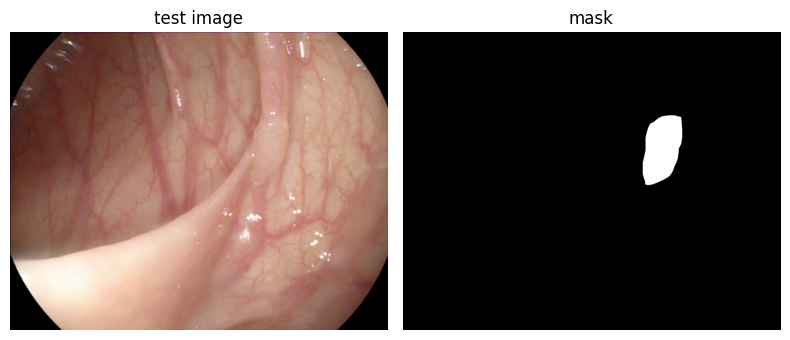

In [9]:
fig = visualize_pair("test", fixed_visual_sample)


## 保存 bootstrap 检查结果

这里把 ETIS 当前划分和统一可视化样本写入 records，作为后续实验的基础记录。


In [10]:
save_json(
    {
        "env_summary": ENV_SUMMARY,
        "dataset": "ETIS",
        "split_summaries": split_summaries,
        "fixed_visual_sample": fixed_visual_sample,
        "pretrained_path": PROJECT_CONFIG["pvt_pretrained_path"],
    },
    ARTIFACTS / "records" / "bootstrap_etis_summary.json",
)
